![image](https://github.com/eWaterCycle/ewatercycle/raw/main/docs/examples/logo.png)

# Generate forcing in eWaterCycle with ESMValTool

This notebooks shows how to generate forcing data for PCR-GLOBWB model using ERA5 data and [ESMValTool hydrological recipes](https://docs.esmvaltool.org/en/latest/recipes/recipe_hydrology.html#pcr-globwb). More information about data, configuration and installation instructions can be found in the [System setup](https://ewatercycle.readthedocs.io/en/latest/system_setup.html) in the eWaterCycle documentation.

In [1]:
import logging
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

logger = logging.getLogger("esmvalcore")
logger.setLevel(logging.WARNING)

In [2]:
import xarray as xr
#from rich import print
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from cartopy import crs
from cartopy import feature as cfeature

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage

In [3]:
import sys
import ewatercycle_pcrglobwb

print("Python:", sys.executable)
print("Package:", ewatercycle_pcrglobwb.__file__)

Python: /home/avandervee3/MSc_AralSea/venv/bin/python
Package: /home/avandervee3/ewatercycle-pcrglobwb/src/ewatercycle_pcrglobwb/__init__.py


In [4]:
import importlib.metadata

print(importlib.metadata.version("ewatercycle-pcrglobwb"))

0.2.1


Forcing for PCRGlobWB is created using the ESMValTool recipe. It produces one file per each variable: temperature, and precipitation. You can set the start and end date, and the region. See [eWaterCycle documentation](https://ewatercycle.readthedocs.io/en/latest/apidocs/ewatercycle.forcing.html#submodules) for more information. 

In [5]:
# pcrglobwb_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].generate(
#     dataset="ERA5",
#     start_time="2015-01-01T00:00:00Z",
#     end_time="2016-12-31T00:00:00Z",
#     shape="./data/Passau/Passau.shp",
#         extract_region={
#         "start_longitude": lon_min_f - esmvaltool_padding,
#         "end_longitude": lon_max_f + esmvaltool_padding,
#         "start_latitude": lat_min_f - esmvaltool_padding,
#         "end_latitude": lat_max_f + esmvaltool_padding,
#     },
#     start_time_climatology="2015-01-01T00:00:00Z",
#     end_time_climatology="2016-12-31T00:00:00Z",
#     directory="./data/forcing/Passau/"
# )

In [6]:
# print(pcrglobwb_forcing)

### Plot forcing

In [7]:
# for file_name in [pcrglobwb_forcing.temperatureNC, pcrglobwb_forcing.precipitationNC]:
#     dataset = xr.load_dataset(f"{pcrglobwb_forcing.directory}/{file_name}")
#     print(dataset)
#     print("------------------------")
#     var = list(dataset.data_vars.keys())[0]
#     dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)

In [8]:


# Catchment bounding boxes
clonemap_extents = {
    "Ebro" : {"latitude" : (39,45), "longitude" : (-6,6)}
}

# Set the extent of the forcing data sufficiently larger than the clonemap.
esmvaltool_padding = 0  # degrees lat/lon



In [9]:
import subprocess
def create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment):
    """Create new clonemap compatible with forcing data resolution."""
    dlon = lonmax - lonmin
    dlat = latmax - latmin

    msg = (
        "The clonemap extent divided by the forcing resolution must yield"
        "an integer number of grid cells."
    )
    assert dlon % forcing_resolution == 0, f"Longitudes not compatible. {msg}"
    assert dlat % forcing_resolution == 0, f"Latitudes not compatible. {msg}"

    clonemap_dir = (
        "/data/shared/parameter-sets/pcrglobwb_global/global_05min/cloneMaps"
    )
    globalclonemap = clonemap_dir + "/clone_global_05min.map"
    outputclonemap = f"./{catchment.lower()}_05min.map"  # copy to clonemap dir after ensuring it is correct

    subprocess.call(
        f"gdal_translate -of PCRaster {globalclonemap} -projwin "
        f"{lonmin} {latmax} {lonmax} {latmin} {outputclonemap}",
        shell=True,
    )
    return outputclonemap



In [10]:


forcing_resolution = 0.75  # this has to be 0.75
for (catchment, extents) in clonemap_extents.items():
    latmin, latmax = extents["latitude"]
    lonmin, lonmax = extents["longitude"]
    print(
        create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment)
    )



Input file size is 4320, 2160
0...10...20...30...40...50...60...70...80...90...100 - done.
./ebro_05min.map


In [11]:

catchment, extents = next(iter(clonemap_extents.items()))

lon_min_f, lon_max_f = extents["longitude"]
lat_min_f, lat_max_f = extents["latitude"]


#forcing_root = Path("/home/avandervee3/ewatercycle-pcrglobwb/docs/data/forcing_example")/ catchment
forcing_root = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/Ebro2/Ebro")
yaml_files = list(forcing_root.rglob("ewatercycle_forcing.yaml"))

if not yaml_files:
    print("Forcing not found — generating.")
    example_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].generate(
        dataset="ERA5",
        start_time="2015-01-01T00:00:00Z",
        end_time="2016-12-31T00:00:00Z",
        shape=f"./data/{catchment}/{catchment}.shp",
        extract_region={
            "start_longitude": lon_min_f - esmvaltool_padding,
            "end_longitude": lon_max_f + esmvaltool_padding,
            "start_latitude": lat_min_f - esmvaltool_padding,
            "end_latitude": lat_max_f + esmvaltool_padding,
        },
        start_time_climatology="2015-01-01T00:00:00Z",
        end_time_climatology="2016-12-31T00:00:00Z",
        directory=forcing_root,
    )

else:
    forcing_yaml = yaml_files[0]
    print(f"Forcing already exists — loading from {forcing_yaml.parent}")

    example_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
        directory=forcing_yaml.parent,
    )

Forcing already exists — loading from /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/Ebro2/Ebro/work/diagnostic/script


<xarray.Dataset> Size: 5MB
Dimensions:    (time: 1096, lat: 25, lon: 49, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 9kB 2014-01-01 2014-01-02 ... 2016-12-31
  * lat        (lat) float32 100B 45.0 44.75 44.5 44.25 ... 39.5 39.25 39.0
  * lon        (lon) float32 196B -5.999 -5.749 -5.499 ... 5.501 5.751 6.001
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 5MB 286.1 286.1 286.1 ... 287.2 287.0
    time_bnds  (time, bnds) datetime64[ns] 18kB 2013-12-31T12:00:00 ... 2016-...
    lat_bnds   (lat, bnds) float32 200B 45.12 44.88 44.88 ... 39.12 39.12 38.88
    lon_bnds   (lon, bnds) float32 392B -6.125 -5.875 -5.875 ... 5.875 6.125
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the PCR-GLOBWB hydrological model.
------------------------
<xarray.Dataset> Size: 5MB
Dimensions:    (time: 1096, lat: 25, lon: 49, bnds: 2)
Coordinates:
  

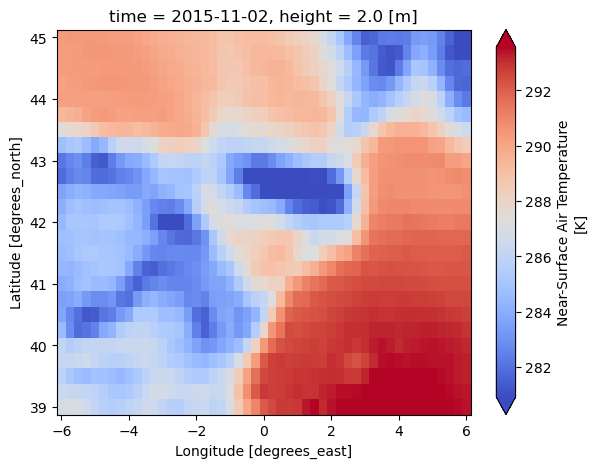

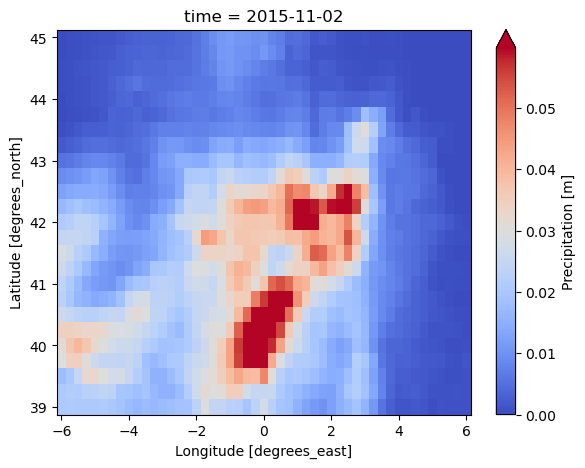

In [12]:
for file_name in [example_forcing.temperatureNC, example_forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{example_forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-426).plot(cmap="coolwarm", robust=True, size=5)

In [13]:

# tools_folder = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/tools")

# rivers_buffer_10km = tools_folder / "aral_basin_ad_sd_rivers_buffer_10_05min_mask.map"

In [14]:


pcr_glob_directory = Path("/data/shared/parameter-sets/pcrglobwb_global")
INI_FILES = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/ini_files")

parameter_set_example = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "uncalibrated_save.ini",
    target_model="pcrglobwb",
    supported_model_versions={"aralxy5"},
)







my_image = ContainerImage("/home/avandervee3/pcrglob_aralxy5.sif")

cloneMap_path = Path.cwd() / f"{catchment.lower()}_05min.map"


#/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/ini_files/calibrated_best_save_discharge.ini



In [15]:
example_forcing

PCRGlobWBForcing(start_time='2015-01-01T00:00:00Z', end_time='2016-12-31T00:00:00Z', directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/Ebro2/Ebro/work/diagnostic/script'), shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/Ebro2/Ebro/work/diagnostic/script/data/Ebro/Ebro.shp'), filenames={}, precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_2015-2016_Ebro.nc', temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_2015-2016_Ebro.nc')

In [16]:
pcrglob_example = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_example,
    forcing=example_forcing,
    cloneMap=cloneMap_path,
    landmask=cloneMap_path,
    bmi_image = my_image
)

print(pcrglob_example)

parameter_set=ParameterSet(name='custom_parameter_set', directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'), config=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/ini_files/uncalibrated_save.ini'), doi='N/A', target_model='pcrglobwb', supported_model_versions={'aralxy5'}, downloader=None) forcing=PCRGlobWBForcing(start_time='2015-01-01T00:00:00Z', end_time='2016-12-31T00:00:00Z', directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/Ebro2/Ebro/work/diagnostic/script'), shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/Ebro2/Ebro/work/diagnostic/script/data/Ebro/Ebro.shp'), filenames={}, precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_2015-2016_Ebro.nc', temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_2015

In [17]:
# Define the short experimental period used for the sensitivity test.
experiment_start_date = "2015-11-01T00:00:00Z"
experiment_end_date = "2016-12-30T00:00:00Z"



# Convert ISO 8601 strings to datetime objects for progress tracking.
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")



Number of days to model: 425


In [18]:
from pathlib import Path
import shutil

# Remove previous experiment directories before setup to keep the notebook reproducible.
for cfg_dir in [
    Path("ebro_experiment"),

]:
    if cfg_dir.exists():
        shutil.rmtree(cfg_dir)

In [19]:
pcrglob_example_config, pcrglob_example_dir = pcrglob_example.setup(
    start_time=experiment_start_date,
    end_time=experiment_end_date,
    max_spinups_in_years=0,
    cfg_dir="ebro_experiment",
)
pcrglob_example_config, pcrglob_example_dir

('/home/avandervee3/ewatercycle-pcrglobwb/docs/ebro_experiment/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/ewatercycle-pcrglobwb/docs/ebro_experiment')

In [20]:
pcrglob_example.initialize(pcrglob_example_config)

In [21]:
for i in tqdm(range(number_of_days), desc="Running pcrglobwb2 experiment"):
    pcrglob_example.update()




    



print("experiments finished.")

Running pcrglobwb2 experiment: 100%|██████████| 425/425 [40:07<00:00,  5.67s/it] 

experiments finished.


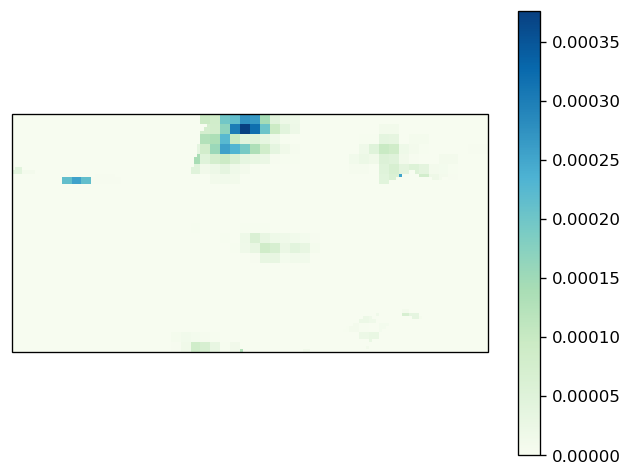

In [22]:

fig = plt.figure(dpi=120)
ax = fig.add_subplot(111, projection=crs.PlateCarree())
# Plotting the model field is a one-liner
pcrglob_example.get_value_as_xarray("precipitation").plot(ax=ax, cmap="GnBu")

# # Also plot the station location
# ax.scatter(grdc_longitude, grdc_latitude, s=25, c="r")

# # Overlay ocean and coastines
# ax.add_feature(cfeature.OCEAN, zorder=2)
# ax.add_feature(cfeature.RIVERS, zorder=2, color="k")
# ax.coastlines(zorder=3)

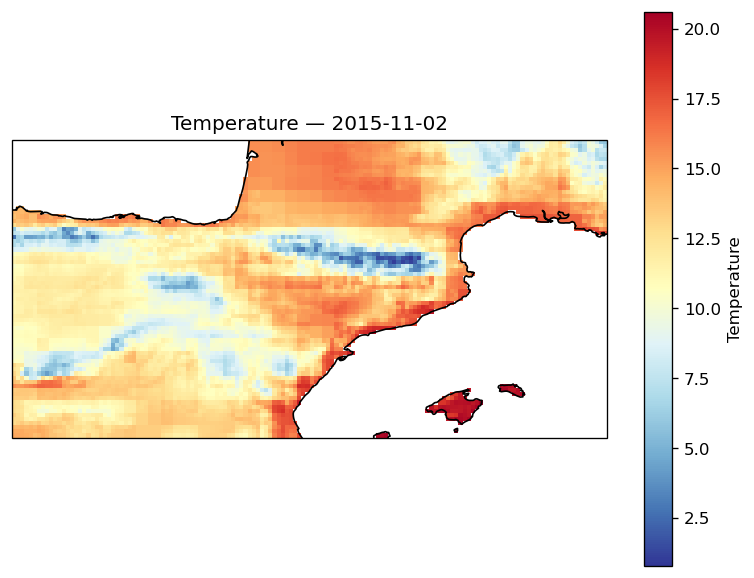

In [23]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

nc_path = "/home/avandervee3/ewatercycle-pcrglobwb/docs/ebro_experiment/netcdf/temperature_dailyTot_output.nc"

ds = xr.open_dataset(nc_path)

fig = plt.figure(figsize=(8, 6), dpi=120)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

ds["temperature"].isel(time=1).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdYlBu_r",
    cbar_kwargs={"label": "Temperature"},
)

ax.coastlines()
ax.set_title(f"Temperature — {ds.time.isel(time=1).dt.strftime('%Y-%m-%d').item()}")

plt.show()

In [24]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

nc_path = "/home/avandervee3/ewatercycle-pcrglobwb/docs/ebro_experiment/netcdf/precipitation_dailyTot_output.nc"

ds = xr.open_dataset(nc_path)

print(ds)
print(ds.data_vars)

<xarray.Dataset> Size: 18MB
Dimensions:        (time: 425, lat: 72, lon: 144)
Coordinates:
  * time           (time) datetime64[ns] 3kB 2015-11-01 ... 2016-12-29
  * lat            (lat) float32 288B 44.96 44.88 44.79 ... 39.21 39.12 39.04
  * lon            (lon) float32 576B -5.958 -5.875 -5.792 ... 5.792 5.875 5.958
Data variables:
    precipitation  (time, lat, lon) float32 18MB ...
Attributes:
    institution:  Department of Physical Geography, Utrecht University
    title:        PCR-GLOBWB 2 output (not coupled to MODFLOW)
    description:  by Edwin H. Sutanudjaja (contact: e.h.sutanudjaja@uu.nl)
Data variables:
    precipitation  (time, lat, lon) float32 18MB ...


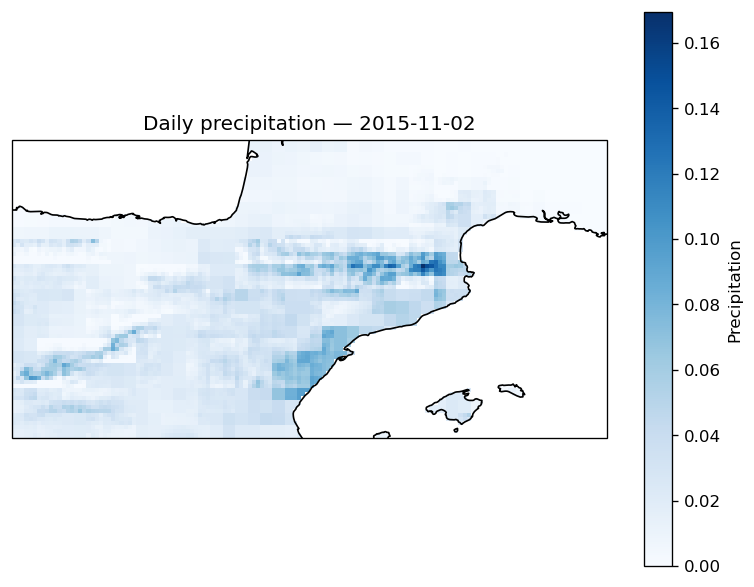

In [25]:
fig = plt.figure(figsize=(8, 6), dpi=120)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

ds["precipitation"].isel(time=1).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    cbar_kwargs={"label": "Precipitation"},
)

ax.coastlines()

date = ds.time.isel(time=1).dt.strftime("%Y-%m-%d").item()
ax.set_title(f"Daily precipitation — {date}")

plt.show()

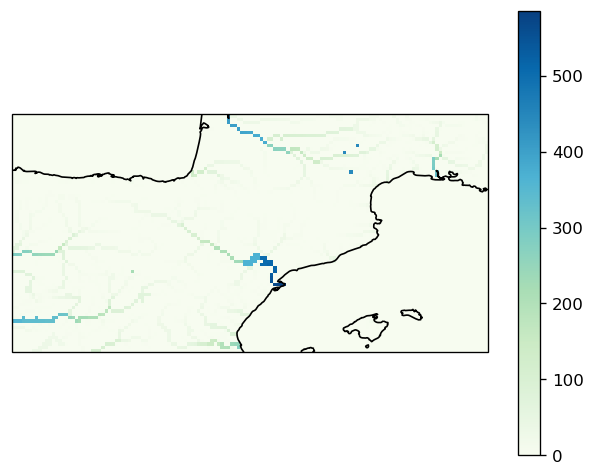

In [26]:
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

shapefile = "/home/avandervee3/ewatercycle-pcrglobwb/docs/data/Passau/Passau.shp"

reader = shpreader.Reader(shapefile)

fig = plt.figure(dpi=120)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

# Discharge
pcrglob_example.get_value_as_xarray("discharge").plot(
    ax=ax,
    cmap="GnBu",
)

# Outline only
for geometry in reader.geometries():
    ax.add_geometries(
        [geometry],
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="red",
        linewidth=0.5,
    )

ax.coastlines()
plt.show()

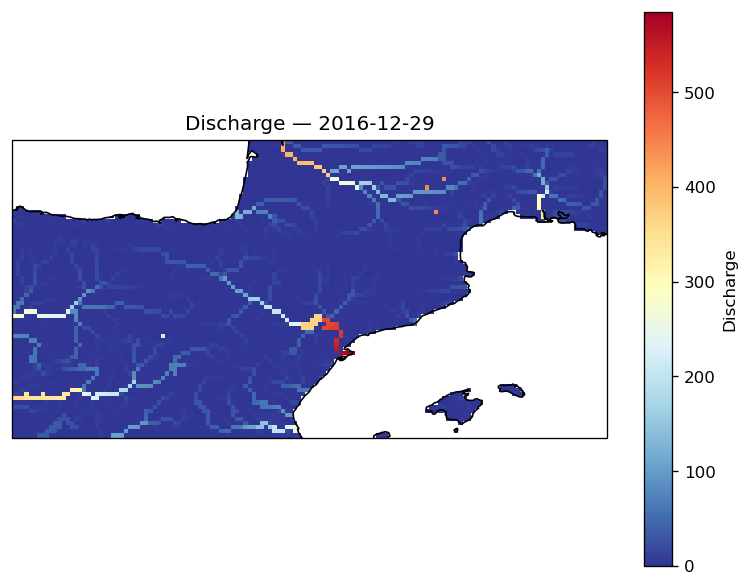

In [37]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

nc_path = "/home/avandervee3/ewatercycle-pcrglobwb/docs/ebro_experiment/netcdf/discharge_dailyTot_output.nc"

ds = xr.open_dataset(nc_path)

fig = plt.figure(figsize=(8, 6), dpi=120)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

ds["discharge"].isel(time=-1).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdYlBu_r",
    cbar_kwargs={"label": "Discharge"},
)

ax.coastlines()
ax.set_title(f"Discharge — {ds.time.isel(time=-1).dt.strftime('%Y-%m-%d').item()}")

plt.show()

Requested: lat=40.81, lon=0.52
Selected:  lat=40.79166793823242, lon=0.5416666865348816


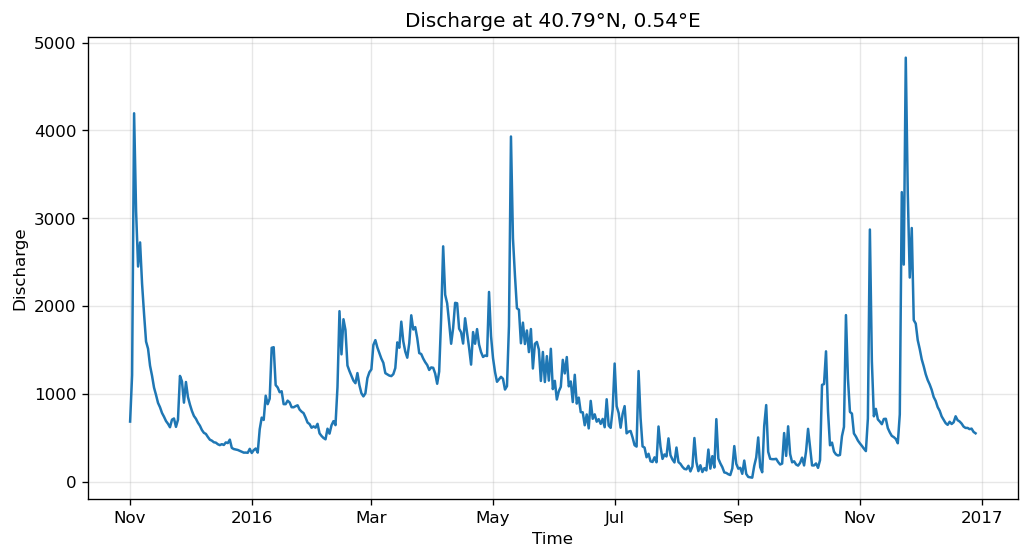

In [38]:
import xarray as xr
import matplotlib.pyplot as plt

nc_path = "/home/avandervee3/ewatercycle-pcrglobwb/docs/ebro_experiment/netcdf/discharge_dailyTot_output.nc"

ds = xr.open_dataset(nc_path)

# Select nearest grid cell to the requested location
point = ds["discharge"].sel(
    lat=40.81,
    lon=0.52,
    method="nearest",
)

print(f"Requested: lat=40.81, lon=0.52")
print(f"Selected:  lat={point.lat.values}, lon={point.lon.values}")

# Plot time series
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

point.plot(ax=ax)

ax.set_xlabel("Time")
ax.set_ylabel("Discharge")
ax.set_title(
    f"Discharge at {point.lat.values:.2f}°N, "
    f"{point.lon.values:.2f}°E"
)

ax.grid(True, alpha=0.3)

plt.show()

In [ ]:
# # eWaterCycle observation module
# from ewatercycle.observation.grdc import get_grdc_data
# station_id = "6233650"

# grdc_start_date = "2000-01-01T00:00:00Z"
# grdc_end_date   = "2016-12-31T00:00:00Z"

In [ ]:
# observations_ds = get_grdc_data(
#     station_id=station_id,
#     start_time=grdc_start_date,
#     end_time=grdc_end_date,
# )

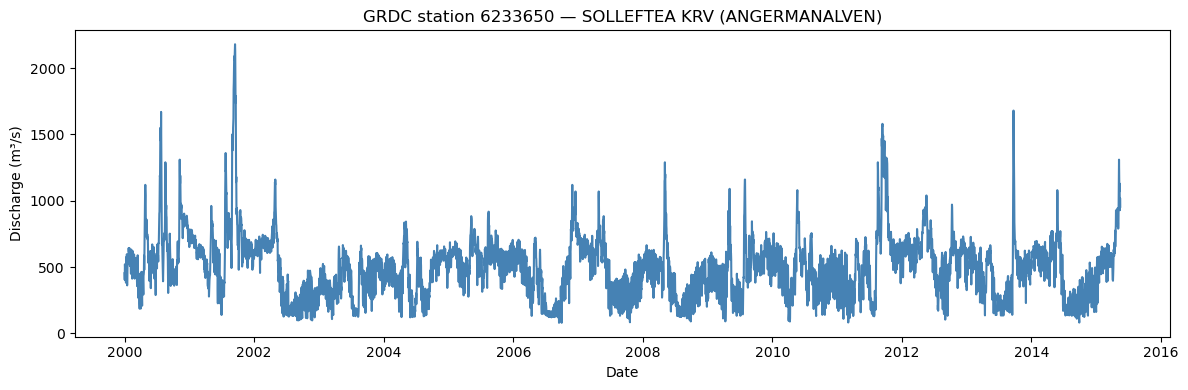

In [ ]:
# station_name = str(observations_ds["station_name"].values)
# river_name   = str(observations_ds["river_name"].values)

# # Mask the -999 missing value sentinel before plotting
# streamflow = observations_ds["streamflow"].where(observations_ds["streamflow"] != -999)

# plt.figure(figsize=(12, 4))
# streamflow.plot(color="steelblue")
# plt.title(f"GRDC station {station_id} — {station_name} ({river_name})")
# plt.xlabel("Date")
# plt.ylabel("Discharge (m³/s)")
# plt.tight_layout()